In [ ]:
!{sys.executable} -m pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir

In [2]:
import sys, subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "torch", "torchvision", "torchaudio", "opacus", "-y"],
    capture_output=True, text=True
)
print(result.stdout[-1000:])

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "torch==2.5.1", "torchvision==0.20.1", "torchaudio==2.5.1",
     "--index-url", "https://download.pytorch.org/whl/cu121", "--no-cache-dir"],
    capture_output=True, text=True
)
print(result.stdout[-1500:])
print(result.stderr[-800:])

Found existing installation: torch 2.12.1
Uninstalling torch-2.12.1:
  Successfully uninstalled torch-2.12.1
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Found existing installation: opacus 1.5.2
Uninstalling opacus-1.5.2:
  Successfully uninstalled opacus-1.5.2

------------------------ 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------- ----------------------------- 1/4 [torch]
   ---------

In [1]:
import sys
print("Executable:", sys.executable)
print("Process ID:", __import__('os').getpid())
import torch
print(torch.__version__)
print(torch.cuda.is_available())

Executable: C:\Users\toky8\miniconda3\envs\cvdl\python.exe
Process ID: 29264
2.5.1+cu121
True


In [4]:
import sys
print(sys.executable)

C:\Users\toky8\miniconda3\envs\cvdl\python.exe


In [5]:
import sys
import subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "torch==2.5.1", "torchvision==0.20.1", "torchaudio==2.5.1",
     "--index-url", "https://download.pytorch.org/whl/cu121", "--no-cache-dir"],
    capture_output=True, text=True
)
print(result.stdout[-2000:])
print(result.stderr[-1000:])

Looking in indexes: https://download.pytorch.org/whl/cu121




In [6]:
import sys
print(sys.executable)
import torch
print(torch.__version__)
print(torch.cuda.is_available())

C:\Users\toky8\miniconda3\envs\cvdl\python.exe
2.5.1+cu121
True


## 0. Setup

In [7]:
import os
os.chdir(r"D:\Study\A_UniVR Class\APAI\APAI_Project")
print("Now in:", os.getcwd())

Now in: D:\Study\A_UniVR Class\APAI\APAI_Project


In [8]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = '/content/drive/MyDrive/APAI_Project'
except ImportError:
    PROJECT = '.'
import sys
sys.path.append(PROJECT)
print("Project path:", PROJECT)

Project path: .


In [9]:
import os
print("Current dir:", os.getcwd())
print("Files:", os.listdir('.'))

Current dir: D:\Study\A_UniVR Class\APAI\APAI_Project
Files: ['checkpoints', 'config.py', 'main.ipynb', 'results', 'src', '__pycache__']


In [10]:
from src import experiments
from src import engine
from src import models
from src import data
from src import continual
from src import distillation
from src import privacy
from src import plots

print("All modules imported successfully!")

All modules imported successfully!


In [13]:
import config
print(dir(config))

['BATCH_SIZE', 'CHECKPOINT_DIR', 'CL_METHODS', 'CONTINUAL_EPOCHS', 'DATASET_A_SLUG', 'DATASET_B_SLUG', 'DISTILL_EPOCHS', 'DP_DELTA', 'DP_EPOCHS', 'DP_EPSILONS', 'DP_MAX_GRAD_NORM', 'DP_MAX_PHYSICAL_BATCH', 'EWC_FISHER_BATCHES', 'EWC_LAMBDA', 'EWC_LAMBDA_SWEEP', 'FIGURE_DIR', 'IMAGENET_MEAN', 'IMAGENET_STD', 'IMAGE_SIZE', 'KD_ALPHA', 'KD_TEMPERATURE', 'LR', 'LWF_ALPHA', 'LWF_TEMPERATURE', 'MAIN_STUDENT', 'MAIN_TEACHER', 'MOMENTUM', 'NUM_CLASSES_A', 'NUM_CLASSES_B', 'NUM_WORKERS', 'OPTIMIZER', 'PROJECT_ROOT', 'RESULTS_DIR', 'SEED', 'STUDENTS', 'TASK_A_CLASSES', 'TASK_B_CLASSES', 'TEACHERS', 'TEACHER_EPOCHS', 'TEST_RATIO', 'TRAIN_CAP', 'TRAIN_RATIO', 'VAL_RATIO', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_d', '_detect_project_root', 'get_device', 'os', 'summary']


In [14]:
config.summary()

PROJECT_ROOT : D:\Study\A_UniVR Class\APAI\APAI_Project
Device       : cuda
Task A        : ['NORMAL', 'PNEUMONIA'] (2 classes)
Task B        : ['glioma', 'meningioma', 'notumor', 'pituitary'] (4 classes)
Teachers      : ['resnet50', 'vit_b_16']
Students      : ['mobilenetv3', 'efficientnet_b0']
CL methods    : ['naive', 'ewc', 'lwf', 'bn_freeze']
Train cap     : 3000


In [15]:
import os
print(os.listdir('checkpoints'))
print(os.listdir('results'))

['cl_mobilenetv3_bn_freeze.pth', 'cl_mobilenetv3_ewc.pth', 'cl_mobilenetv3_lwf.pth', 'cl_mobilenetv3_naive.pth', 'cl_resnet50__mobilenetv3_naive.pth', 'student_resnet50__mobilenetv3.pth', 'student_taskA_mobilenetv3.pth', 'teacher_resnet50.pth']
['cl_comparison.csv', 'figures', 'privacy_results.csv']


In [16]:
import pandas as pd

print("=== cl_comparison.csv ===")
cl_df = pd.read_csv("results/cl_comparison.csv")
print(cl_df)

print("\n=== privacy_results.csv ===")
priv_df = pd.read_csv("results/privacy_results.csv")
print(priv_df)

=== cl_comparison.csv ===
       student     method  TaskA_retention_%  TaskA_acc  TaskB_acc
0  mobilenetv3  bn_freeze             100.00     0.9818     0.8861
1  mobilenetv3        lwf              84.82     0.8328     0.9583
2  mobilenetv3        ewc              76.36     0.7497     0.9120
3  mobilenetv3      naive              74.28     0.7292     0.9454

=== privacy_results.csv ===
       epsilon  TaskA_acc  MIA_AUC
0  inf (no DP)     0.9147   0.5461
1          8.0     0.7292   0.5266
2          3.0     0.7292   0.5186
3          1.0     0.7292   0.5273


In [17]:
with open("src/continual.py") as f:
    print(f.read())

"""
src/continual.py
Stage 3 â€” Continual Learning. Adapt the distilled student to Task B (brain MRI)
WITHOUT access to Task A data, using four strategies, then measure how much of
Task A is forgotten.

Strategies
----------
  naive      : just fine-tune on Task B            (baseline / lower bound)
  ewc        : Elastic Weight Consolidation        (Fisher-weighted penalty)
  lwf        : Learning without Forgetting          (distill old Task-A outputs)
  bn_freeze  : freeze the ENTIRE backbone (incl. BN running stats + affine
               params) and only train the Task-B head (architectural
               stabilization / upper bound on retention)

Each method starts from the SAME distilled student (a fresh copy), so the
comparison is fair.

Public API:
    continual_train(student_state, method, task_A_data, task_B_data, student_name)
        -> trained model
    run_all_methods(student_state, task_A_data, task_B_data, ref_acc, student_name)
        -> pandas.DataFrame of results


In [18]:
with open("src/privacy.py") as f:
    print(f.read())

"""
src/privacy.py
Stage 4 â€” Privacy (the novel contribution).

Two parts:
  1. Membership Inference Attack (MIA): can an attacker tell whether a sample
     was in the model's TRAINING set? Members tend to have LOWER loss than
     non-members; we score by -loss and report attack AUC.
       AUC ~ 0.50  -> no leakage (good for privacy)
       AUC  > 0.50 -> the model leaks membership

  2. Differential Privacy (DP-SGD): retrain on Task A with clipped per-sample
     gradients + calibrated Gaussian noise (privacy budget epsilon). We then
     measure accuracy and MIA together to chart the privacy-utility trade-off.

IMPORTANT â€” WHY THIS VERSION DOES NOT USE OPACUS
-------------------------------------------------
The original implementation used the `opacus` library for DP-SGD. In
practice, getting a torch/opacus version pair that imports cleanly on this
machine turned out to be unreliable: several opacus releases pull in
`torch.distributed` submodules that only exist in very speci

In [19]:
!pip install -q opacus kagglehub scikit-learn

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.5.1+cu121 requires torch==2.5.1+cu121, but you have torch 2.12.1 which is incompatible.
torchvision 0.20.1+cu121 requires torch==2.5.1+cu121, but you have torch 2.12.1 which is incompatible.


In [20]:
import importlib
import config
importlib.reload(config)   # pick up any edits to config.py
config.summary()

PROJECT_ROOT : D:\Study\A_UniVR Class\APAI\APAI_Project
Device       : cuda
Task A        : ['NORMAL', 'PNEUMONIA'] (2 classes)
Task B        : ['glioma', 'meningioma', 'notumor', 'pituitary'] (4 classes)
Teachers      : ['resnet50', 'vit_b_16']
Students      : ['mobilenetv3', 'efficientnet_b0']
CL methods    : ['naive', 'ewc', 'lwf', 'bn_freeze']
Train cap     : 3000


## 1. Data — Task A (Chest X-ray) & Task B (Brain MRI)

In [21]:
from src import data
path_a, path_b = data.download_datasets()
task_A = data.build_task("A", path_a)
task_B = data.build_task("B", path_b)

Task A folder: C:\Users\toky8\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
Task B folder: C:\Users\toky8\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
[Task A] classes=['NORMAL', 'PNEUMONIA']  train=3000 val=878 test=879
[Task B] classes=['glioma', 'meningioma', 'notumor', 'pituitary']  train=3000 val=1080 test=1080


In [ ]:
# quick visual check
data.show_samples(task_A)
data.show_samples(task_B)

In [ ]:
print(task_A["classes"] if "classes" in task_A else "task_A still loaded")

## 2. Models

In [22]:
from src import models, engine
models.describe_all()

Teachers:
  resnet50         23.51 M
  vit_b_16         85.80 M
Students (multi-head):
  mobilenetv3      3.96 M
  efficientnet_b0  5.32 M


In [23]:
print("Teacher epochs:", config.TEACHER_EPOCHS)
print("Distill epochs:", config.DISTILL_EPOCHS)
print("Continual epochs:", config.CONTINUAL_EPOCHS)
print("DP epochs:", config.DP_EPOCHS)

Teacher epochs: 5
Distill epochs: 5
Continual epochs: 8
DP epochs: 5


## 3. Stage 1 — Teacher (ResNet-50) on Task A
Loads the checkpoint if present, otherwise trains once.

In [24]:
teacher = models.build_teacher("resnet50")
if engine.checkpoint_exists("teacher_resnet50"):
    teacher = engine.load_checkpoint(teacher, "teacher_resnet50")
else:
    teacher, _ = engine.train_supervised(
        teacher, task_A["train_loader"], task_A["val_loader"],
        weights=task_A["class_weights"], task=None,
        epochs=config.TEACHER_EPOCHS)
    engine.save_checkpoint(teacher, "teacher_resnet50")

D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\teacher_resnet50.pth


In [25]:
rep = engine.full_report(teacher, task_A["test_loader"],
                         task=None, class_names=task_A["class_names"])
print(f"Teacher Task A accuracy: {rep['acc']:.4f}   AUC: {rep['auc']:.4f}")
print(rep["report_text"])

Teacher Task A accuracy: 0.9659   AUC: 0.9911
              precision    recall  f1-score   support

      NORMAL     0.9407    0.9328    0.9367       238
   PNEUMONIA     0.9751    0.9782    0.9766       641

    accuracy                         0.9659       879
   macro avg     0.9579    0.9555    0.9567       879
weighted avg     0.9658    0.9659    0.9658       879



## 4. Stage 2 — Knowledge Distillation (Teacher → Student)
Loads the distilled student if present, otherwise distills once.

In [26]:
from src import distillation
student = models.build_student("mobilenetv3")
if engine.checkpoint_exists("student_taskA_mobilenetv3"):
    student = engine.load_checkpoint(student, "student_taskA_mobilenetv3")
else:
    student, _ = distillation.distill(teacher, student, task_A)
    engine.save_checkpoint(student, "student_taskA_mobilenetv3")

D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\student_taskA_mobilenetv3.pth


In [27]:
rep_s = engine.full_report(student, task_A["test_loader"],
                           task="a", class_names=task_A["class_names"])
REF_TASK_A_ACC = rep_s["acc"]
print(f"Student Task A accuracy: {rep_s['acc']:.4f}  (teacher {rep['acc']:.4f})")
print(f"Student AUC: {rep_s['auc']:.4f}")
print("Reference Task A acc (before Task B):", REF_TASK_A_ACC)

Student Task A accuracy: 0.9818  (teacher 0.9659)
Student AUC: 0.9941
Reference Task A acc (before Task B): 0.981797497155859


## 5. Stage 3 — Continual Learning to Task B
Trains four strategies and compares Task-A retention vs Task-B accuracy.
Set `FORCE_RETRAIN = False` to reuse saved CL checkpoints (fast).

In [28]:
from src import continual
import pandas as pd

FORCE_RETRAIN = False

ckpts = [f"cl_mobilenetv3_{m}" for m in config.CL_METHODS]
have_all = all(engine.checkpoint_exists(c) for c in ckpts)

if (not FORCE_RETRAIN) and have_all:
    rows, cl_models = [], {}
    for m in config.CL_METHODS:
        mdl = models.build_student("mobilenetv3")
        mdl = engine.load_checkpoint(mdl, f"cl_mobilenetv3_{m}")
        cl_models[m] = mdl
        accA = engine.evaluate(mdl, task_A["test_loader"], "a")["acc"]
        accB = engine.evaluate(mdl, task_B["test_loader"], "b")["acc"]
        rows.append({"student": "mobilenetv3", "method": m,
                     "TaskA_retention_%": round(engine.retention(accA, REF_TASK_A_ACC), 2),
                     "TaskA_acc": round(accA, 4), "TaskB_acc": round(accB, 4)})
    cl_df = pd.DataFrame(rows).sort_values("TaskA_retention_%", ascending=False)
else:
    cl_df, cl_models = continual.run_all_methods(
        student_state=student.state_dict(),
        task_A_data=task_A, task_B_data=task_B,
        ref_acc=REF_TASK_A_ACC, student_name="mobilenetv3")

print("\n===== Continual Learning Comparison =====")
print(cl_df.to_string(index=False))
cl_df.to_csv(f"{config.RESULTS_DIR}/cl_comparison.csv", index=False)

D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_mobilenetv3_naive.pth
loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_mobilenetv3_ewc.pth
loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_mobilenetv3_lwf.pth
loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_mobilenetv3_bn_freeze.pth

===== Continual Learning Comparison =====
    student    method  TaskA_retention_%  TaskA_acc  TaskB_acc
mobilenetv3 bn_freeze             100.00     0.9818     0.8861
mobilenetv3       lwf              84.82     0.8328     0.9583
mobilenetv3       ewc              76.36     0.7497     0.9120
mobilenetv3     naive              74.28     0.7292     0.9454


In [29]:
priv_df = privacy.run_dp_study(task_A)
print("\n===== Privacy-Utility Trade-off =====")
print(priv_df.to_string(index=False))
priv_df.to_csv(f"{config.RESULTS_DIR}/privacy_results.csv", index=False)
print("saved:", f"{config.RESULTS_DIR}/privacy_results.csv")

================================================== non-private (overfit on 800 imgs, 25 ep)
  [no-DP] epoch 1/25
  [no-DP] epoch 2/25
  [no-DP] epoch 3/25
  [no-DP] epoch 4/25
  [no-DP] epoch 5/25
  [no-DP] epoch 6/25
  [no-DP] epoch 7/25
  [no-DP] epoch 8/25
  [no-DP] epoch 9/25
  [no-DP] epoch 10/25
  [no-DP] epoch 11/25
  [no-DP] epoch 12/25
  [no-DP] epoch 13/25
  [no-DP] epoch 14/25
  [no-DP] epoch 15/25
  [no-DP] epoch 16/25
  [no-DP] epoch 17/25
  [no-DP] epoch 18/25
  [no-DP] epoch 19/25
  [no-DP] epoch 20/25
  [no-DP] epoch 21/25
  [no-DP] epoch 22/25
  [no-DP] epoch 23/25
  [no-DP] epoch 24/25
  [no-DP] epoch 25/25
  -> acc=0.927  MIA AUC=0.550
================================================== DP-SGD  eps=8.0
  [DP eps=8.0] noise_multiplier=0.469 steps=375 sample_rate=0.040
  [DP eps=8.0] epoch 1/15
  [DP eps=8.0] epoch 2/15
  [DP eps=8.0] epoch 3/15
  [DP eps=8.0] epoch 4/15
  [DP eps=8.0] epoch 5/15
  [DP eps=8.0] epoch 6/15
  [DP eps=8.0] epoch 7/15
  [DP eps=8.0] epoch 8

In [30]:
print("Current EWC_LAMBDA:", config.EWC_LAMBDA)

Current EWC_LAMBDA: 50000.0


In [31]:
import inspect
from src import privacy
print(inspect.getsource(privacy._build_resnet18))

def _build_resnet18(num_classes):
    """A small CNN (GroupNorm, no in-place ops) used for the DP study.
    Kept the name _build_resnet18 so the rest of the file / notebook is
    unchanged. GroupNorm (rather than BatchNorm) is used because BatchNorm
    statistics mix information across the batch, which complicates
    per-sample gradient computation in DP-SGD; GroupNorm normalizes each
    sample independently and has no such issue."""
    class DPNet(nn.Module):
        def __init__(self, n):
            super().__init__()
            def block(ci, co):
                return nn.Sequential(
                    nn.Conv2d(ci, co, 3, padding=1),
                    nn.GroupNorm(8, co),
                    nn.ReLU(inplace=False),
                    nn.MaxPool2d(2),
                )
            self.features = nn.Sequential(
                block(3, 32), block(32, 64),
                block(64, 128), block(128, 128),
                nn.AdaptiveAvgPool2d((2, 2)),
            )
        

## 6. Stage 4 — Privacy (novel contribution)

### 6.1 Membership Inference Attack
Does the continual model leak whether a patient was in the Task-A training set?
AUC ~ 0.50 = no leak; higher = leakage.

In [32]:
import inspect
from src import privacy
print("_leaky_train_loader" in dir(privacy))   

True


In [33]:
from src import privacy

best_method = cl_df.iloc[0]["method"]            # highest retention
best_model = models.build_student("mobilenetv3")
best_model = engine.load_checkpoint(best_model, f"cl_mobilenetv3_{best_method}")

mia = privacy.membership_inference_auc(
    best_model,
    member_loader=task_A["train_eval_loader"],
    nonmember_loader=task_A["test_loader"],
    task="a")
print(f"Best CL method: {best_method}")
print(f"MIA AUC (continual student, Task A): {mia:.3f}")
print("0.50 = no leak, higher = leaks membership")

D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_mobilenetv3_bn_freeze.pth
Best CL method: bn_freeze
MIA AUC (continual student, Task A): 0.508
0.50 = no leak, higher = leaks membership


### 6.2 Differential Privacy (DP-SGD)
Trains ResNet-18 on Task A with/without DP and charts the privacy–utility
trade-off. **Heavy: trains 4 models, ~20–30 min.**

In [36]:
priv_df = privacy.run_dp_study(task_A, dp_epochs=10)
print("\n===== Privacy-Utility Trade-off =====")
print(priv_df.to_string(index=False))
priv_df.to_csv(f"{config.RESULTS_DIR}/privacy_results.csv", index=False)

================================================== non-private (overfit on 800 imgs, 25 ep)
  [no-DP] epoch 1/25
  [no-DP] epoch 2/25
  [no-DP] epoch 3/25
  [no-DP] epoch 4/25
  [no-DP] epoch 5/25
  [no-DP] epoch 6/25
  [no-DP] epoch 7/25
  [no-DP] epoch 8/25
  [no-DP] epoch 9/25
  [no-DP] epoch 10/25
  [no-DP] epoch 11/25
  [no-DP] epoch 12/25
  [no-DP] epoch 13/25
  [no-DP] epoch 14/25
  [no-DP] epoch 15/25
  [no-DP] epoch 16/25
  [no-DP] epoch 17/25
  [no-DP] epoch 18/25
  [no-DP] epoch 19/25
  [no-DP] epoch 20/25
  [no-DP] epoch 21/25
  [no-DP] epoch 22/25
  [no-DP] epoch 23/25
  [no-DP] epoch 24/25
  [no-DP] epoch 25/25
  -> acc=0.944  MIA AUC=0.549
================================================== DP-SGD  eps=8.0
  [DP eps=8.0] noise_multiplier=0.383 steps=250 sample_rate=0.040
  [DP eps=8.0] epoch 1/10
  [DP eps=8.0] epoch 2/10
  [DP eps=8.0] epoch 3/10
  [DP eps=8.0] epoch 4/10
  [DP eps=8.0] epoch 5/10
  [DP eps=8.0] epoch 6/10
  [DP eps=8.0] epoch 7/10
  [DP eps=8.0] epoch 8

In [37]:
import torch
from src import privacy, models

device = config.get_device()
model = privacy._build_resnet18(2).to(device)
crit = torch.nn.CrossEntropyLoss()

xb, yb = next(iter(task_A["train_loader"]))
xb, yb = xb.to(device), yb.to(device)
xb, yb = xb[:8], yb[:8]   # small batch for testing

params = privacy._compute_per_sample_grads(model, crit, xb, yb)
print("grad_sample shape (first param):", params[0].grad_sample.shape)
print("grad_sample norm (first param, first sample):", params[0].grad_sample[0].norm().item())

norms = privacy._per_sample_grad_norms(model, params)
print("Per-sample total grad norms:", norms)

grad_sample shape (first param): torch.Size([8, 32, 3, 3, 3])
grad_sample norm (first param, first sample): 0.708568274974823
Per-sample total grad norms: 

ImportError: cannot import name '_normalize_function_or_error' from 'torch.fx.operator_schemas' (C:\Users\toky8\miniconda3\envs\cvdl\lib\site-packages\torch\fx\operator_schemas.py)

In [38]:
norms = privacy._per_sample_grad_norms(model, params)
print("Per-sample total grad norms:", norms.detach().cpu().numpy())

Per-sample total grad norms: [13.986085 16.75772  15.31788  14.588482 12.324095 10.134183 15.260328
 15.272634]


In [39]:
model.zero_grad(set_to_none=True)
params2 = privacy._compute_per_sample_grads(model, crit, xb, yb)

opt_test = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

# Save weights before
w_before = [p.clone().detach() for p in params2]

privacy._dp_sgd_step(model, params2, opt_test, max_grad_norm=1.0, noise_multiplier=0.3, lr=0.05)

# Check if weights actually changed
for i, p in enumerate(params2[:3]):
    diff = (p.detach() - w_before[i]).abs().sum().item()
    print(f"param {i}: weight change = {diff:.6f}")

param 0: weight change = 1.259446
param 1: weight change = 0.043346
param 2: weight change = 0.037283


In [40]:
import numpy as np
from collections import Counter

leaky_loader, member_idx = privacy._leaky_train_loader(task_A, subset=800)
labels = []
for xb, yb in leaky_loader:
    labels.extend(yb.numpy().tolist())
print("Class distribution in leaky subset:", Counter(labels))
print("Class weights being used:", task_A["class_weights"])

Class distribution in leaky subset: Counter({1: 596, 0: 204})
Class weights being used: 

ImportError: cannot import name '_normalize_function_or_error' from 'torch.fx.operator_schemas' (C:\Users\toky8\miniconda3\envs\cvdl\lib\site-packages\torch\fx\operator_schemas.py)

In [41]:
print("Class weights:", task_A["class_weights"].detach().cpu().numpy())

Class weights: [1.867995  0.6827492]


In [50]:
import importlib
import config
importlib.reload(config)
print("LR_DP:", config.LR_DP)
print("DP_EPOCHS:", config.DP_EPOCHS)

LR_DP: 0.02
DP_EPOCHS: 15


In [51]:
from src import privacy
importlib.reload(privacy)

<module 'src.privacy' from 'D:\\Study\\A_UniVR Class\\APAI\\APAI_Project\\src\\privacy.py'>

In [52]:
priv_df = privacy.run_dp_study(task_A, dp_epochs=15)
print("\n===== Privacy-Utility Trade-off =====")
print(priv_df.to_string(index=False))
priv_df.to_csv(f"{config.RESULTS_DIR}/privacy_results.csv", index=False)
print("saved")

================================================== non-private (overfit on 800 imgs, 25 ep)
  [no-DP] epoch 1/25
  [no-DP] epoch 2/25
  [no-DP] epoch 3/25
  [no-DP] epoch 4/25
  [no-DP] epoch 5/25
  [no-DP] epoch 6/25
  [no-DP] epoch 7/25
  [no-DP] epoch 8/25
  [no-DP] epoch 9/25
  [no-DP] epoch 10/25
  [no-DP] epoch 11/25
  [no-DP] epoch 12/25
  [no-DP] epoch 13/25
  [no-DP] epoch 14/25
  [no-DP] epoch 15/25
  [no-DP] epoch 16/25
  [no-DP] epoch 17/25
  [no-DP] epoch 18/25
  [no-DP] epoch 19/25
  [no-DP] epoch 20/25
  [no-DP] epoch 21/25
  [no-DP] epoch 22/25
  [no-DP] epoch 23/25
  [no-DP] epoch 24/25
  [no-DP] epoch 25/25
  -> acc=0.927  MIA AUC=0.532
================================================== DP-SGD  eps=8.0
  [DP eps=8.0] noise_multiplier=0.469 steps=375 sample_rate=0.040
  [DP eps=8.0] epoch 1/15
  [DP eps=8.0] epoch 2/15
  [DP eps=8.0] epoch 3/15
  [DP eps=8.0] epoch 4/15
  [DP eps=8.0] epoch 5/15
  [DP eps=8.0] epoch 6/15
  [DP eps=8.0] epoch 7/15
  [DP eps=8.0] epoch 8

In [60]:
import importlib
from src import privacy
importlib.reload(privacy)

<module 'src.privacy' from 'D:\\Study\\A_UniVR Class\\APAI\\APAI_Project\\src\\privacy.py'>

In [61]:
priv_df = privacy.run_dp_study(task_A, dp_epochs=15)
print("\n===== Privacy-Utility Trade-off =====")
print(priv_df.to_string(index=False))
priv_df.to_csv(f"{config.RESULTS_DIR}/privacy_results.csv", index=False)

================================================== non-private (overfit on 800 imgs, 25 ep)
  [no-DP] epoch 1/25
  [no-DP] epoch 2/25
  [no-DP] epoch 3/25
  [no-DP] epoch 4/25
  [no-DP] epoch 5/25
  [no-DP] epoch 6/25
  [no-DP] epoch 7/25
  [no-DP] epoch 8/25
  [no-DP] epoch 9/25
  [no-DP] epoch 10/25
  [no-DP] epoch 11/25
  [no-DP] epoch 12/25
  [no-DP] epoch 13/25
  [no-DP] epoch 14/25
  [no-DP] epoch 15/25
  [no-DP] epoch 16/25
  [no-DP] epoch 17/25
  [no-DP] epoch 18/25
  [no-DP] epoch 19/25
  [no-DP] epoch 20/25
  [no-DP] epoch 21/25
  [no-DP] epoch 22/25
  [no-DP] epoch 23/25
  [no-DP] epoch 24/25
  [no-DP] epoch 25/25
  -> acc=0.919  MIA AUC=0.526
================================================== DP-SGD  eps=8.0
  [DP eps=8.0] noise_multiplier=0.469 steps=375 sample_rate=0.040
  [DP eps=8.0] epoch 1/15
  [DP eps=8.0] epoch 2/15
  [DP eps=8.0] epoch 3/15
  [DP eps=8.0] epoch 4/15
  [DP eps=8.0] epoch 5/15
  [DP eps=8.0] epoch 6/15
  [DP eps=8.0] epoch 7/15
  [DP eps=8.0] epoch 8

In [62]:
import inspect
print(inspect.getsource(experiments.run_pair))

def run_pair(teacher_name, student_name, task_A, task_B,
             force_retrain=False, save=True):
    """Teacher -> distill -> 4 continual methods, for one (teacher, student)."""
    tag = f"{teacher_name}__{student_name}"
    print("#" * 60)
    print(f"#  PAIR: teacher={teacher_name}   student={student_name}")
    print("#" * 60)

    # ---- 1. teacher (shared across students -> keyed by teacher only) ----
    teacher = models.build_teacher(teacher_name)
    tkey = f"teacher_{teacher_name}"
    if engine.checkpoint_exists(tkey) and not force_retrain:
        teacher = engine.load_checkpoint(teacher, tkey)
    else:
        print(f"[{tag}] training teacher {teacher_name} ...")
        teacher, _ = engine.train_supervised(
            teacher, task_A["train_loader"], task_A["val_loader"],
            weights=task_A["class_weights"], task=None,
            epochs=config.TEACHER_EPOCHS)
        if save:
            engine.save_checkpoint(teacher, tkey)

    # ---- 2. distill into th

Option 3- pair 1 cell (privacy):

In [63]:
from src import experiments
df1 = experiments.run_pair("resnet50", "mobilenetv3", task_A, task_B)
print(df1.to_string(index=False))

############################################################
#  PAIR: teacher=resnet50   student=mobilenetv3
############################################################


D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\teacher_resnet50.pth
loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\student_resnet50__mobilenetv3.pth
[resnet50__mobilenetv3] reference Task A acc = 0.9727
loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_resnet50__mobilenetv3_naive.pth
   -> A=0.871  B=0.927  retention=89.6%
[resnet50__mobilenetv3] continual: ewc
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_resnet50__mobilenetv3_ewc.pth
   -> A=0.914  B=0.940  retention=93.9%
[resnet50__mobilenetv3] continual: lwf
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_resnet50__mobilenetv3_lwf.pth
   -> A=0.729  B=0.951  retention=75.0%
[resnet50__mobilenetv3] continual: bn_freeze
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_resnet50__mobilenetv3_bn_freeze.pth
   -> A=0.973  B=0.900  retention=100.0%
 teacher     student    method  TaskA_retention_%  TaskA_acc  TaskB_acc
resnet50 mobilenetv3     naive  

Cell — pair 2:

In [64]:
df2 = experiments.run_pair("resnet50", "efficientnet_b0", task_A, task_B)
print(df2.to_string(index=False))

############################################################
#  PAIR: teacher=resnet50   student=efficientnet_b0
############################################################


D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\teacher_resnet50.pth
[resnet50__efficientnet_b0] distilling -> efficientnet_b0 ...
  epoch 1/5  loss=0.443  val_acc(A)=0.936
  epoch 2/5  loss=0.245  val_acc(A)=0.969
  epoch 3/5  loss=0.170  val_acc(A)=0.978
  epoch 4/5  loss=0.155  val_acc(A)=0.961
  epoch 5/5  loss=0.147  val_acc(A)=0.970
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\student_resnet50__efficientnet_b0.pth
[resnet50__efficientnet_b0] reference Task A acc = 0.9647
[resnet50__efficientnet_b0] continual: naive
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_resnet50__efficientnet_b0_naive.pth
   -> A=0.404  B=0.973  retention=41.9%
[resnet50__efficientnet_b0] continual: ewc
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_resnet50__efficientnet_b0_ewc.pth
   -> A=0.922  B=0.967  retention=95.5%
[resnet50__efficientnet_b0] continual: lwf
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_resnet50__efficientn

Cell — pair 3 (ViT,):

In [65]:
df3 = experiments.run_pair("vit_b_16", "mobilenetv3", task_A, task_B)
print(df3.to_string(index=False))

############################################################
#  PAIR: teacher=vit_b_16   student=mobilenetv3
############################################################
[vit_b_16__mobilenetv3] training teacher vit_b_16 ...
  epoch 1/5  train_loss=0.782  val_acc=0.730
  epoch 2/5  train_loss=0.623  val_acc=0.705
  epoch 3/5  train_loss=0.554  val_acc=0.837
  epoch 4/5  train_loss=0.475  val_acc=0.847
  epoch 5/5  train_loss=0.486  val_acc=0.845
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\teacher_vit_b_16.pth
[vit_b_16__mobilenetv3] distilling -> mobilenetv3 ...
  epoch 1/5  loss=0.195  val_acc(A)=0.815
  epoch 2/5  loss=0.170  val_acc(A)=0.940
  epoch 3/5  loss=0.161  val_acc(A)=0.972
  epoch 4/5  loss=0.160  val_acc(A)=0.956
  epoch 5/5  loss=0.152  val_acc(A)=0.952
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\student_vit_b_16__mobilenetv3.pth
[vit_b_16__mobilenetv3] reference Task A acc = 0.9704
[vit_b_16__mobilenetv3] continual: naive
saved: D:\Study\A

Cell — pair 4 (ViT,):

In [66]:
df4 = experiments.run_pair("vit_b_16", "efficientnet_b0", task_A, task_B)
print(df4.to_string(index=False))

############################################################
#  PAIR: teacher=vit_b_16   student=efficientnet_b0
############################################################


D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\teacher_vit_b_16.pth
[vit_b_16__efficientnet_b0] distilling -> efficientnet_b0 ...
  epoch 1/5  loss=0.208  val_acc(A)=0.943
  epoch 2/5  loss=0.177  val_acc(A)=0.961
  epoch 3/5  loss=0.168  val_acc(A)=0.969
  epoch 4/5  loss=0.161  val_acc(A)=0.960
  epoch 5/5  loss=0.160  val_acc(A)=0.941
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\student_vit_b_16__efficientnet_b0.pth
[vit_b_16__efficientnet_b0] reference Task A acc = 0.9727
[vit_b_16__efficientnet_b0] continual: naive
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_vit_b_16__efficientnet_b0_naive.pth
   -> A=0.271  B=0.966  retention=27.8%
[vit_b_16__efficientnet_b0] continual: ewc
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_vit_b_16__efficientnet_b0_ewc.pth
   -> A=0.580  B=0.956  retention=59.6%
[vit_b_16__efficientnet_b0] continual: lwf
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_vit_b_16__efficientn

Cell — all pair one table:

In [67]:
import pandas as pd
full = pd.concat([df1, df2, df3, df4], ignore_index=True)
print(full.to_string(index=False))
full.to_csv(f"{config.RESULTS_DIR}/all_pairs.csv", index=False)
print("saved all_pairs.csv")

 teacher         student    method  TaskA_retention_%  TaskA_acc  TaskB_acc
resnet50     mobilenetv3     naive              89.59     0.8714     0.9269
resnet50     mobilenetv3       ewc              93.92     0.9135     0.9398
resnet50     mobilenetv3       lwf              74.97     0.7292     0.9509
resnet50     mobilenetv3 bn_freeze             100.00     0.9727     0.9000
resnet50 efficientnet_b0     naive              41.86     0.4039     0.9731
resnet50 efficientnet_b0       ewc              95.52     0.9215     0.9667
resnet50 efficientnet_b0       lwf              76.89     0.7418     0.9704
resnet50 efficientnet_b0 bn_freeze             100.00     0.9647     0.9046
vit_b_16     mobilenetv3     naive              67.88     0.6587     0.9583
vit_b_16     mobilenetv3       ewc              81.83     0.7941     0.9259
vit_b_16     mobilenetv3       lwf              75.15     0.7292     0.9787
vit_b_16     mobilenetv3 bn_freeze             100.00     0.9704     0.8685
vit_b_16 eff

Cell — λ sweep (ablation):

In [68]:
student = models.build_student("mobilenetv3")
student = engine.load_checkpoint(student, "student_resnet50__mobilenetv3")
ref = engine.evaluate(student, task_A["test_loader"], "a")["acc"]
sweep = experiments.run_lambda_sweep(student.state_dict(), task_A, task_B, ref)
print(sweep.to_string(index=False))

D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\student_resnet50__mobilenetv3.pth
[lambda sweep] lambda=0
   -> retention=86.3%  B=0.933
[lambda sweep] lambda=500
   -> retention=95.0%  B=0.959
[lambda sweep] lambda=2000
   -> retention=95.4%  B=0.966
[lambda sweep] lambda=8000
   -> retention=90.6%  B=0.931
 lambda  TaskA_retention_%  TaskB_acc
      0              86.32     0.9333
    500              94.97     0.9593
   2000              95.44     0.9657
   8000              90.64     0.9306


In [69]:
sweep.to_csv(f"{config.RESULTS_DIR}/lambda_sweep.csv", index=False)
print("saved lambda_sweep.csv")

saved lambda_sweep.csv


In [70]:
import inspect
print(inspect.getsource(plots))

"""
src/plots.py
All figures for the paper. Each function saves a PNG into results/figures/
and also shows it inline.

Public API:
    plot_confusion(y_true, y_pred, class_names, title, fname)
    plot_roc(y_true, y_prob, title, fname)                    # binary (Task A)
    plot_loss_curve(history, title, fname)
    plot_retention_bar(cl_df, fname)
    plot_stability_plasticity(cl_df, fname)
    plot_privacy_tradeoff(priv_df, fname)
    plot_lambda_sweep(sweep_df, fname)
    plot_pairs_grouped(all_pairs_df, fname)
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

import config


def _save(fig, fname):
    path = os.path.join(config.FIGURE_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("saved:", path)


# --------------------------------------------------------------------------- #
#  CONFUSION MATRIX
# ---------------------------------------------------------

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\retention_bar.png


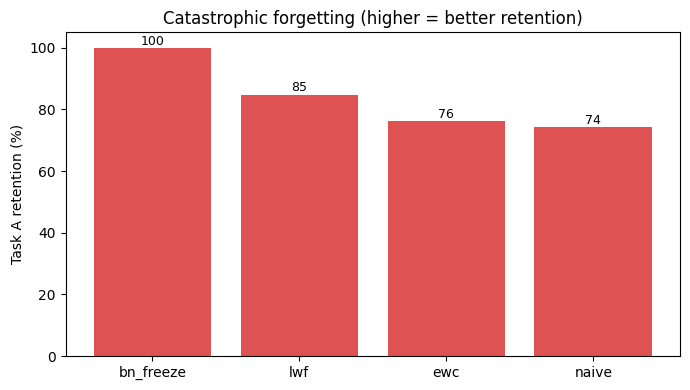

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\stability_plasticity.png


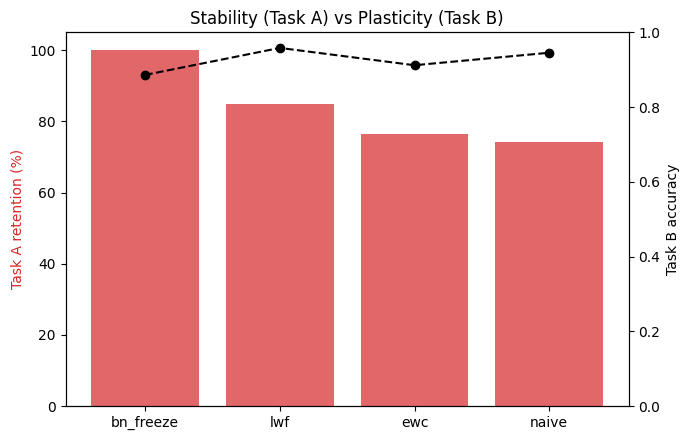

In [71]:
plots.plot_retention_bar(cl_df, fname="retention_bar.png")
plots.plot_stability_plasticity(cl_df, fname="stability_plasticity.png")

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\privacy_tradeoff.png


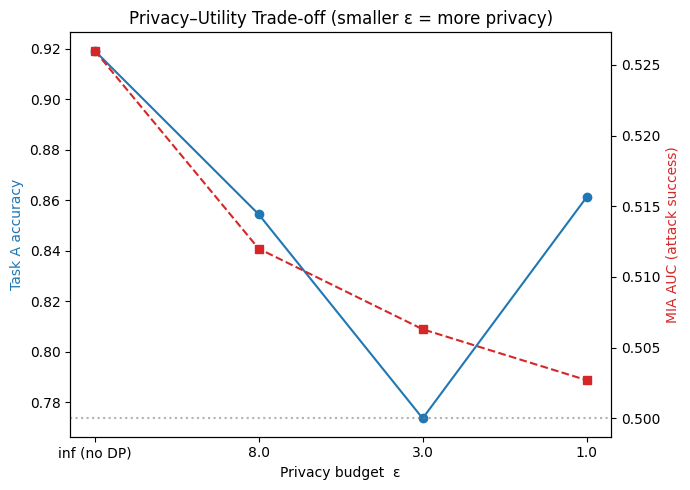

In [72]:
plots.plot_privacy_tradeoff(priv_df, fname="privacy_tradeoff.png")

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\lambda_sweep.png


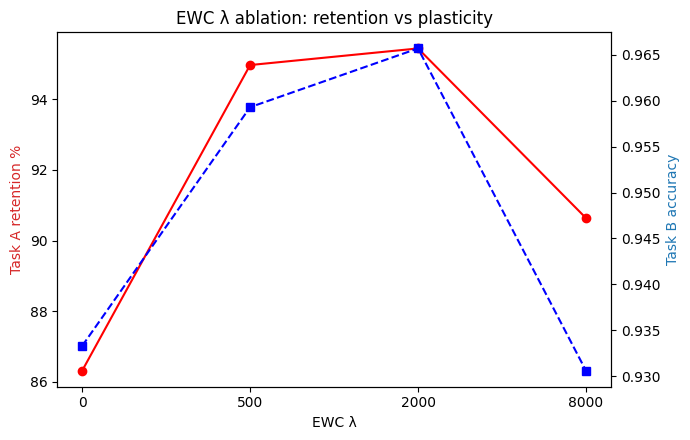

In [73]:
plots.plot_lambda_sweep(sweep, fname="lambda_sweep.png")

In [75]:
import pandas as pd
all_pairs_df = pd.read_csv(f"{config.RESULTS_DIR}/all_pairs.csv")
print(all_pairs_df)

     teacher          student     method  TaskA_retention_%  TaskA_acc  \
0   resnet50      mobilenetv3      naive              89.59     0.8714   
1   resnet50      mobilenetv3        ewc              93.92     0.9135   
2   resnet50      mobilenetv3        lwf              74.97     0.7292   
3   resnet50      mobilenetv3  bn_freeze             100.00     0.9727   
4   resnet50  efficientnet_b0      naive              41.86     0.4039   
5   resnet50  efficientnet_b0        ewc              95.52     0.9215   
6   resnet50  efficientnet_b0        lwf              76.89     0.7418   
7   resnet50  efficientnet_b0  bn_freeze             100.00     0.9647   
8   vit_b_16      mobilenetv3      naive              67.88     0.6587   
9   vit_b_16      mobilenetv3        ewc              81.83     0.7941   
10  vit_b_16      mobilenetv3        lwf              75.15     0.7292   
11  vit_b_16      mobilenetv3  bn_freeze             100.00     0.9704   
12  vit_b_16  efficientnet_b0      nai

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\all_pairs_retention.png


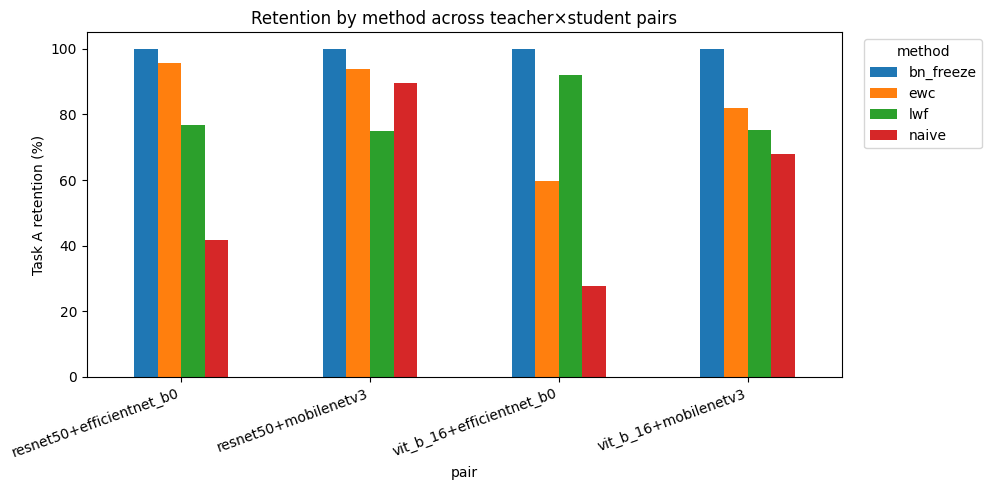

In [76]:
plots.plot_pairs_grouped(all_pairs_df, fname="all_pairs_retention.png")

Plots — cells (experiments)


Cell — teacher ROC + confusion (Task A):

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\teacher_roc.png


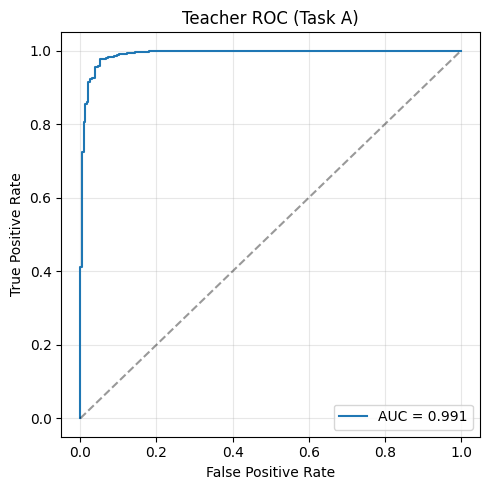

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\teacher_confusion.png


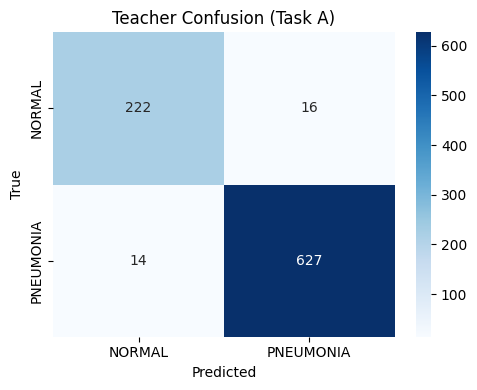

In [77]:
from src import plots
rep = engine.full_report(teacher, task_A["test_loader"], task=None,
                         class_names=task_A["class_names"])
plots.plot_roc(rep["y_true"], rep["y_prob"], "Teacher ROC (Task A)", "teacher_roc.png")
plots.plot_confusion(rep["y_true"], rep["y_pred"], task_A["class_names"],
                     "Teacher Confusion (Task A)", "teacher_confusion.png")

Cell — continual retention + stability/plasticity:

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\retention_bar.png


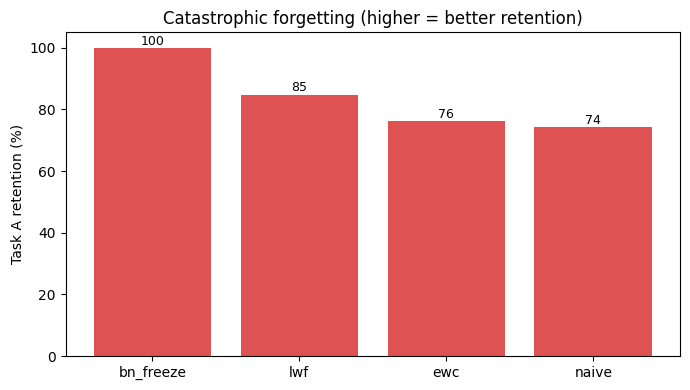

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\stability_plasticity.png


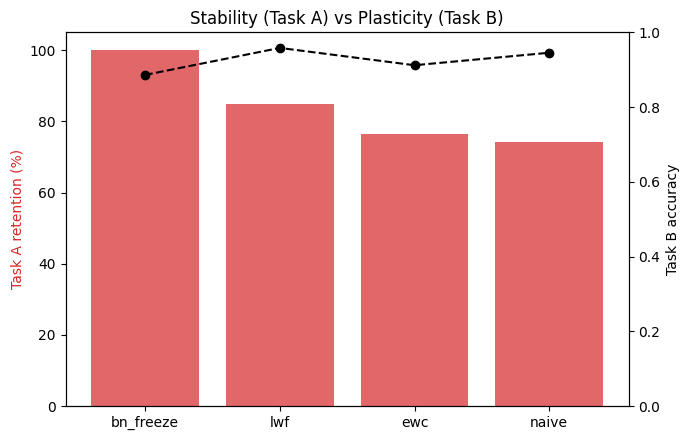

In [78]:
# cl_df =  continual comparison table (Stage 3 )
plots.plot_retention_bar(cl_df, "retention_bar.png")
plots.plot_stability_plasticity(cl_df, "stability_plasticity.png")

Cell — best continual model-এর confusion (Task A + B):

D:\Study\A_UniVR Class\APAI\APAI_Project\src\engine.py:182: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=config.get_devi

loaded: D:\Study\A_UniVR Class\APAI\APAI_Project\checkpoints\cl_mobilenetv3_bn_freeze.pth
saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\best_taskA_cm.png


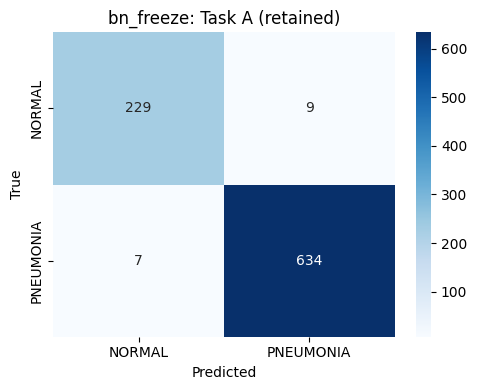

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\best_taskB_cm.png


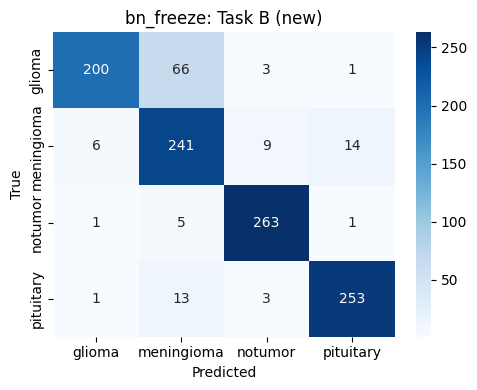

In [79]:
best = cl_df.iloc[0]["method"]
m = engine.load_checkpoint(models.build_student("mobilenetv3"), f"cl_mobilenetv3_{best}")
rA = engine.full_report(m, task_A["test_loader"], "a", task_A["class_names"])
rB = engine.full_report(m, task_B["test_loader"], "b", task_B["class_names"])
plots.plot_confusion(rA["y_true"], rA["y_pred"], task_A["class_names"],
                     f"{best}: Task A (retained)", "best_taskA_cm.png")
plots.plot_confusion(rB["y_true"], rB["y_pred"], task_B["class_names"],
                     f"{best}: Task B (new)", "best_taskB_cm.png")

Cell — privacy tradeoff:

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\privacy_tradeoff.png


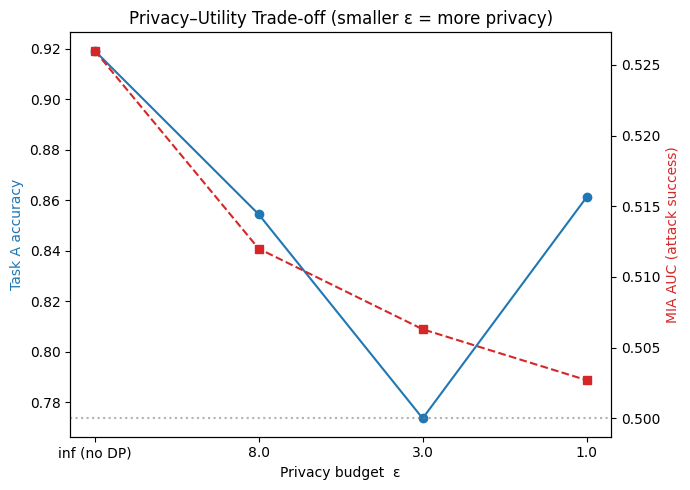

In [80]:
import pandas as pd
priv_df = pd.read_csv(f"{config.RESULTS_DIR}/privacy_results.csv")
plots.plot_privacy_tradeoff(priv_df, "privacy_tradeoff.png")

Cell — λ sweep:

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\lambda_sweep.png


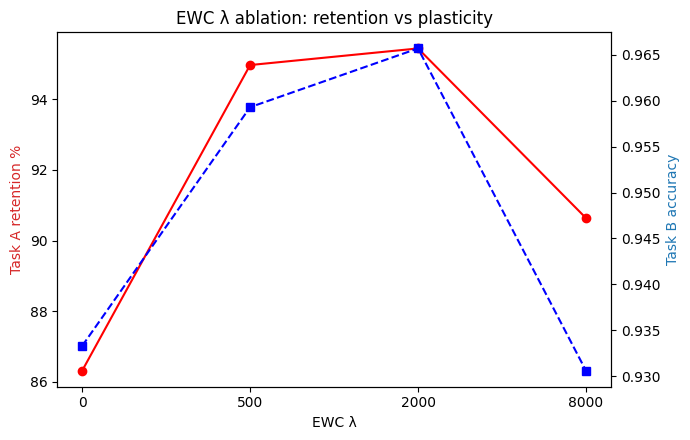

In [81]:
plots.plot_lambda_sweep(sweep, "lambda_sweep.png")

Cell — all pairs grouped (Option 3):

saved: D:\Study\A_UniVR Class\APAI\APAI_Project\results\figures\all_pairs_retention.png


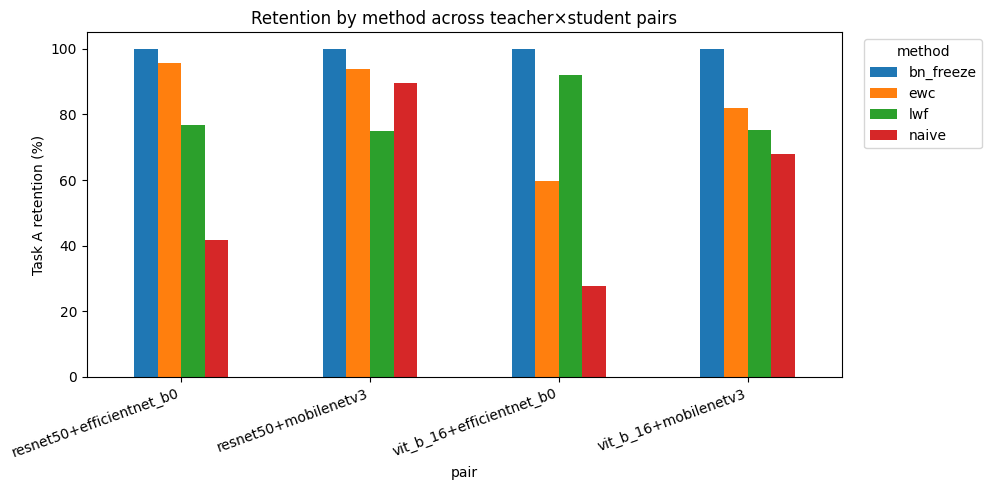

In [82]:
plots.plot_pairs_grouped(full, "all_pairs_retention.png")

Setup → Data → Models
Stage 1: Teacher (load/train)
Stage 2: Distillation (load/train)
REF
Stage 3: Continual (4 method)
Stage 4: Privacy — MIA + DP study
Option 3: pair 1,2,3,4 → all_pairs table → λ sweep
Plots: ROC, confusion, retention, stability, privacy, λ, all-pairs